**SEE ONENOTE FOR TODOS**

https://docs.mondaic.com/2024.1.3/examples/tutorials/sources_and_receivers/custom_stf/tutorial

In [24]:
%matplotlib inline 

In [25]:
# Imports
import os
import pathlib
import urllib.request

# Site name for Salvus Flow. Uses env var if available, otherwise falls back to local site name.
SALVUS_FLOW_SITE_NAME = os.environ.get("SALVUS_FLOW_SITE_NAME", "salome_remote_2")
PROJECT_DIR = "simulation_wavefield_custom_stf_rolled" 

# Conservative default to reduce license-seat demand during unstable license-server periods.
RANKS_PER_JOB = 4


def check_license_server_reachable(url="https://l.mondaic.com/licensing_server", timeout=10):
    """Fail fast if licensing endpoint is unreachable to avoid long hanging jobs."""
    try:
        with urllib.request.urlopen(url, timeout=timeout):
            return True
    except Exception as exc:
        raise RuntimeError(
            f"Licensing server not reachable ({url}). Retry later or check network/VPN. Original error: {exc}"
        ) from exc


# Add code to keep .gitignore updated to ignore salvus files
gitignore_path = pathlib.Path("..") / ".gitignore"
with open(gitignore_path, "r+") as f:
    contents = f.read()
    if PROJECT_DIR not in contents:
        f.write(f"\n{PROJECT_DIR}/\n")


import numpy as np
import salvus.namespace as sn
import salvus.flow.simple_config as sc
import xarray as xr
import salvus.namespace as sn
from salvus.project.tools.processing import block_processing
from salvus.toolbox.helpers.wavefield_output import (
    WavefieldOutput,
    wavefield_output_to_xarray,
)
import matplotlib.pyplot as plt
from matplotlib import animation
import obspy

# For wavefield output code
from salvus.mesh.unstructured_mesh_utils import read_model_from_h5
from salvus.toolbox.helpers import wavefield_output
import salvus.flow.api

#for plotting of wiggles, traces 
from scipy import signal

# For animation plot
from IPython.display import HTML
from matplotlib.collections import PolyCollection
import threading
import matplotlib
matplotlib.use("Agg")
from scipy.interpolate import griddata

In [26]:
# Setup of the model domain as a box (same as research module)
domain_2d = sn.domain.dim2.BoxDomain(x0=0, x1=400, y0=0, y1=3)
p = sn.Project.from_domain(path=PROJECT_DIR, domain=domain_2d, load_if_exists=True)

Accordion()

[2026-06-12 15:30:33,002] INFO: Loading project from simulation_wavefield_custom_stf_rolled.


Calculated time step between sources based on target velocity: 0.0056 s
Plotting source index 0 at x = 30.0 m (delay = 0.0000 s):


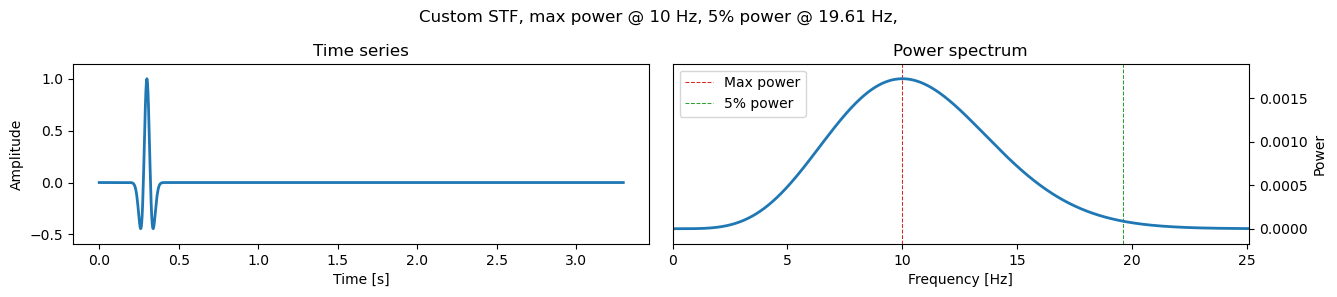

Plotting source index 100 at x = 80.0 m (delay = 0.5556 s):


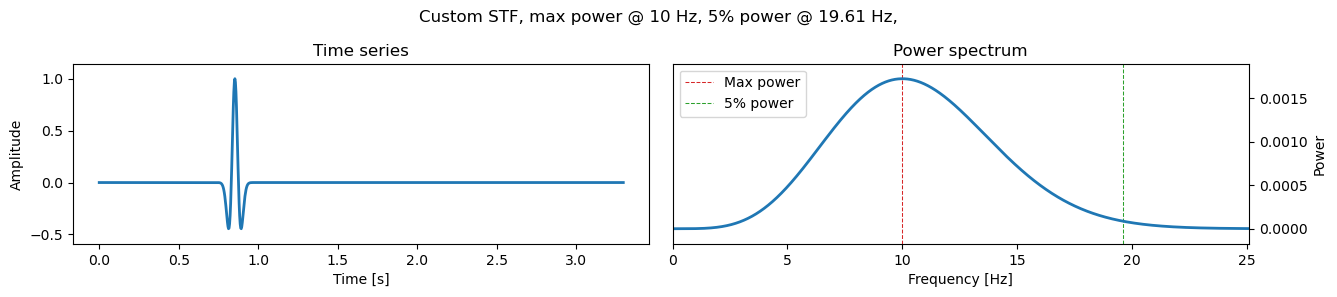

Plotting source index 200 at x = 130.0 m (delay = 1.1111 s):


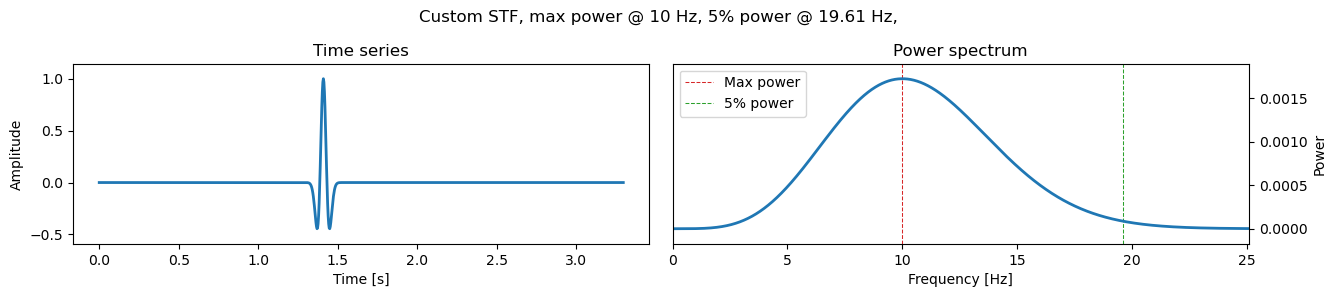

Plotting source index 300 at x = 180.0 m (delay = 1.6667 s):


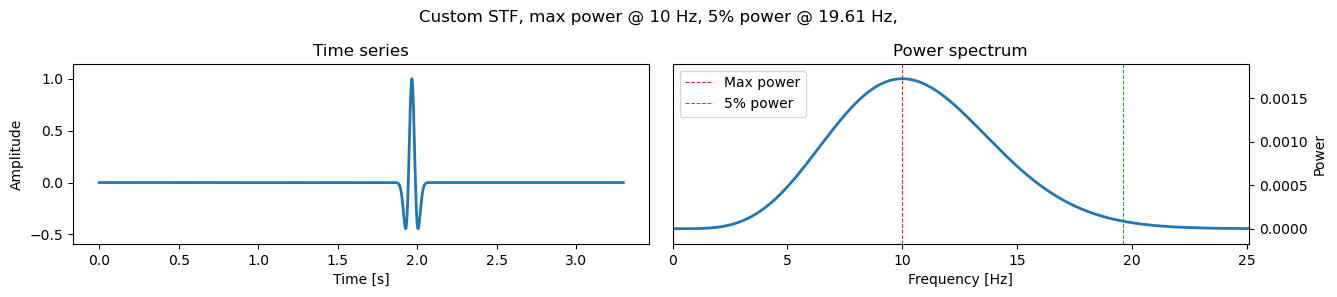

Plotting source index 400 at x = 230.0 m (delay = 2.2222 s):


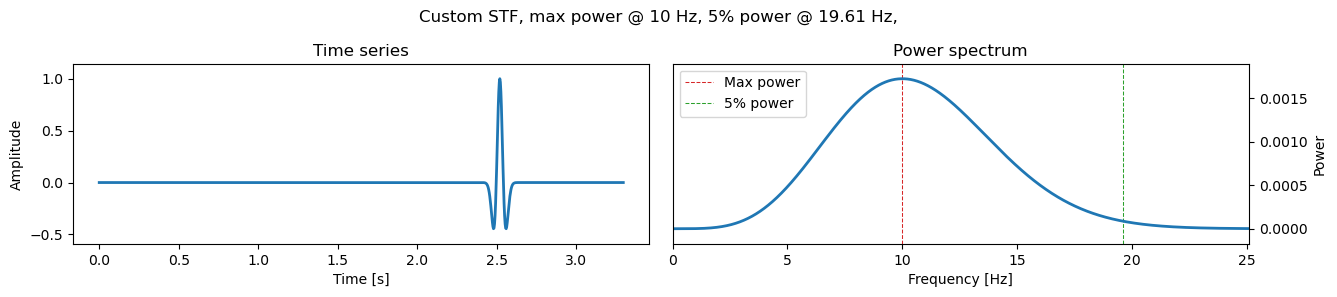

In [ ]:
# # Defining custom ricker wavelet 
# # formula for ricker from seg wiki: f(t)=(1-2\pi ^{2}f_{_{M}}^{2}t^{2})e^{-\pi ^{2}f_{_{M}}^{2}t^{2}}
# f0 = 10 # central frequency in HZ
# sampling_rate = 300 # in HZ
# t = np.arange(-0.3, 3.0, 1/sampling_rate) # time vector from -0.3 to 3 seconds with step of 1/sampling_rate FOR THE ENTIRE SIMULATION

# steps = 0.5 # distance between the sources in m
# x_positions = np.arange(30.0, 270.0, steps) # source positions from 30 to 270 m with step 
# target_vprop = 90 # target velocity, sub-rayleigh or supershear
# dx = x_positions[1] - x_positions[0]
# dt_src = dx / target_vprop
# print(f"Calculated time step between sources based on target velocity: {dt_src:.4f} s") # This needs to be input in roll 



# y_src = 2.625

# # create empthy source list to which the sources will be added 
# srcs = []

# # Looping over the source positions and time delays 
# for i, x_src in enumerate(x_positions):
#     relative_delay = i * dt_src # is the delay of each source relative to the first source
#     shift_samples = int(relative_delay * sampling_rate) # relative delay in sampkles

#     wavelet_base = (1.0 - 2.0 * (np.pi * f0 * t) ** 2) * np.exp(-((np.pi * f0 * t) ** 2)) # ricker wave equation 

#     wavelet_delayed = np.roll(wavelet_base, shift_samples)

#     stf = sc.stf.Custom.from_array(
#         array=wavelet_delayed,
#         sampling_rate_in_hertz=sampling_rate,
#         start_time_in_seconds=0.0
#     )




#     # Plotting in 50m steps: this is 100*i because the steps are 0.5 m and we want to plot every 5 m, so we plot every 10th source
#     plotting_steps = np.arange(0, len(x_positions), 100)
#     if i in plotting_steps:
#         print(f"Plotting source index {i} at x = {x_src} m (delay = {relative_delay:.4f} s):")
#         stf.plot()
#         fig = plt.gcf()
#         from IPython.display import display
#         display(fig)
#         plt.close(fig)


#     src = sc.source.cartesian.MomentTensorPoint2D(
#         x=x_src,  
#         y=y_src,
#         mxx=0.0,
#         myy=-1.54e+01,
#         mxy=0.0,
#         source_time_function=stf
#     )

#     srcs.append(src)


Plotting source index 0 at x = 30.0 m (calculated delay = 0.0000 s):


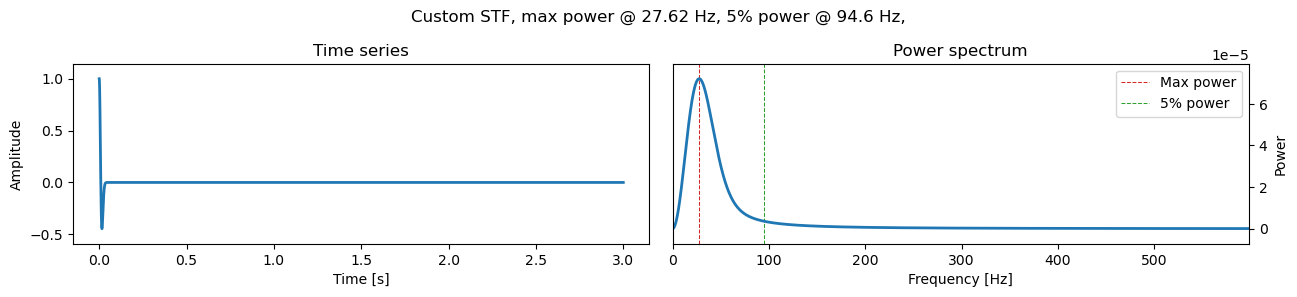

Plotting source index 100 at x = 80.0 m (calculated delay = 0.5000 s):


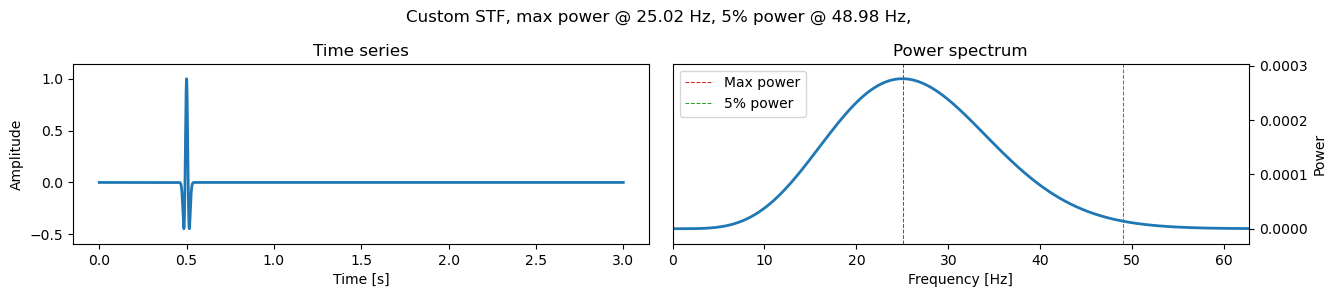

Plotting source index 200 at x = 130.0 m (calculated delay = 1.0000 s):


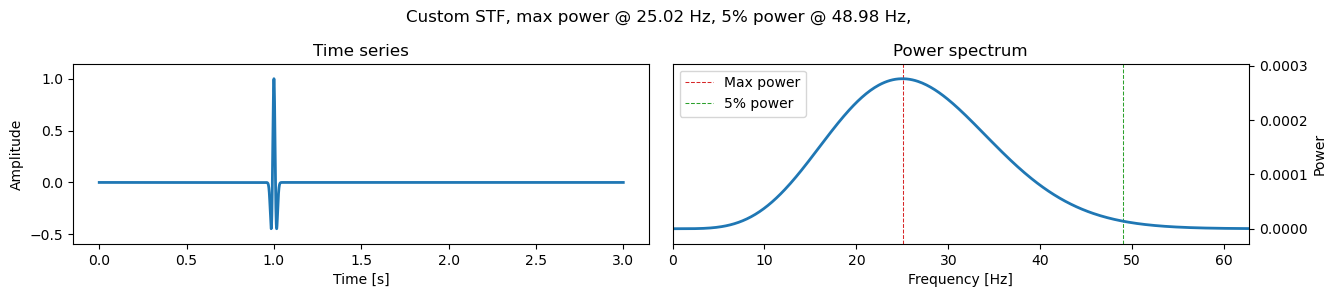

Plotting source index 300 at x = 180.0 m (calculated delay = 1.5000 s):


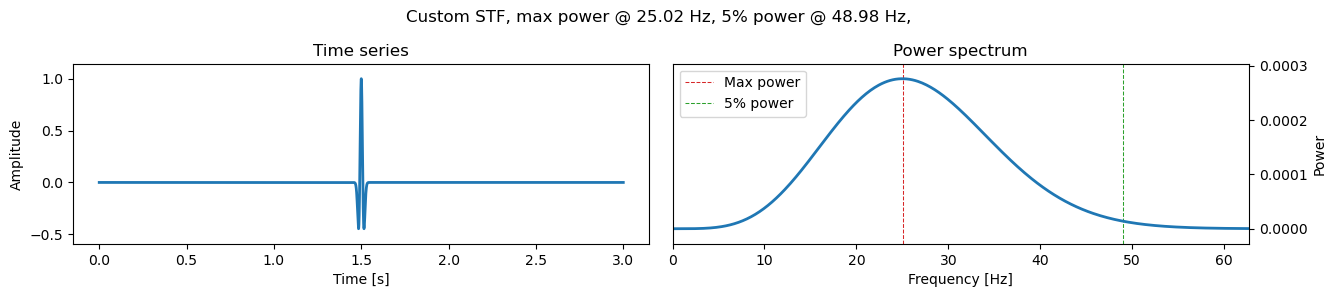

Plotting source index 400 at x = 230.0 m (calculated delay = 2.0000 s):


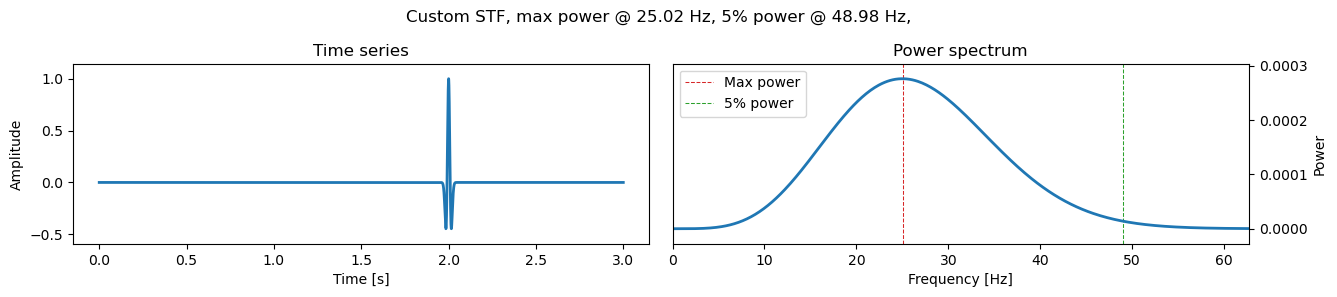

Successfully generated 480 sequentially delayed sources.


In [ ]:


# SImulation constants
f0 = 25.0# Center frequency of Ricker(Hz)
sampling_rate = 10000.0 # Sampling rate (Hz)
dt = 1.0 / sampling_rate # Time step in seconds
t_max = 3.0 # Total simulation duration (seconds)

# Fixed delay step between consecutive sources (seconds)
# calculating this from x positions
step = 0.5 # distance between the sources in m
x_positions = np.arange(30.0, 270.0, step)
target_vprop = 90 # target velocity, sub-rayleigh or supershear
delay_between_sources = step / target_vprop
print(f"Calculated time step between sources based on target velocity: {delay_between_sources:.4f} s") 
y_src = 2.625             

# Define a local symmetric time window for a single base wavelet
wavelet_half_width = 0.08  
t_local = np.arange(-wavelet_half_width, wavelet_half_width, dt)

# Create the master timeline that matches  full simulation duration
t_sim = np.arange(0, t_max, dt)

# Generate symmetric base Ricker wavelet centered at t_local = 0
wavelet_base = (1.0 - 2.0 * (np.pi * f0 * t_local) ** 2) * np.exp(-((np.pi * f0 * t_local) ** 2))


srcs = []

for i, x_src in enumerate(x_positions):
    # Calculate relative delay based on the source index
    relative_delay = i * delay_between_sources
    
    # Initialize an empty master simulation timeline for this specific source
    wavelet_delayed = np.zeros_like(t_sim)
    
    # Map the local centered wavelet samples to their delayed index window
    center_sample = int(relative_delay * sampling_rate)
    half_samples = len(wavelet_base) // 2
    
    start_idx = center_sample - half_samples
    end_idx = center_sample + half_samples
    
    # Safely insert the wavelet within the boundaries of the master simulation time
    if end_idx > 0 and start_idx < len(t_sim):
        sim_slice = slice(max(0, start_idx), min(len(t_sim), end_idx))
        wav_slice = slice(max(0, -start_idx), min(len(wavelet_base), len(t_sim) - start_idx))
        wavelet_delayed[sim_slice] = wavelet_base[wav_slice]

    # Initialize the custom STF forcing start_time_in_seconds to 0
    stf = sc.stf.Custom.from_array(
        array=wavelet_delayed,
        sampling_rate_in_hertz=sampling_rate,
        start_time_in_seconds=0.0
    )
    
    # Optional plotting to verify the shifting works visually before launch
    plotting_steps = np.arange(0, len(x_positions), 100)
    if i in plotting_steps:
        print(f"Plotting source index {i} at x = {x_src} m (calculated delay = {relative_delay:.4f} s):")
        stf.plot()
        fig = plt.gcf()
        from IPython.display import display
        display(fig)
        plt.close(fig)

    # Wrap inside Salvus point source configuration
    src = sc.source.cartesian.MomentTensorPoint2D(
        x=x_src,  
        y=y_src,  # Taken from your notebook configuration profile
        mxx=0.0,
        myy=-1.54e+01,
        mxy=0.0,
        source_time_function=stf
    )

    srcs.append(src)

print(f"Successfully generated {len(srcs)} sequentially delayed sources.")

In [12]:
# fig,ax = plt.subplots()
# array=(1.0 - 2.0 * (np.pi * f0 * t) ** 2) * np.exp(-((np.pi * f0 * t) ** 2)),

# ax.plot(array[0])
# ax.plot(np.roll(array[0], 10))
# display(fig)
# #plt.close(fig)

In [13]:
# array[0]

In [14]:

# Layered model setup: three layers ordered as snow, slab, air (top to bottom).

x_min, x_max = 0.0, 400.0

# Geometry (y-coordinates: higher = higher depth, measured downward):
# Snow: from y=3.0 m (top) to y=2.25 m
# Slab: from y=2.25 m to y=1.5 m  
# Air:  from y=1.5 m to y=0.0 m (bottom)

slab_top = 3.0
slab_bottom = 2.25
wl_top = 2.25
wl_bottom = 1.5
air_top = 1.5
air_bottom = 0.0

# Boundaries from top to bottom -> 3 layers.
# Must be strictly ordered: top to bottom (decreasing y).
layers_x = [
    np.array([x_min, x_max]),  # snow top boundary
    np.array([x_min, x_max]),  # snow-slab interface
    np.array([x_min, x_max]),  # slab-air interface
    np.array([x_min, x_max]),  # air bottom boundary
]
layers_y = [
    np.array([slab_top, slab_top]),      # y = 3.0
    np.array([slab_bottom, slab_bottom]),  # y = 2.25
    np.array([wl_bottom, wl_bottom]),  # y = 1.5
    np.array([air_bottom, air_bottom]),    # y = 0.0
]

# Material parameters by region index [snow, slab, air].
vp = np.array([332.0, 300.0, 300.0]) 
vs = np.array([150.0, 150.0, 0.0])   
rho = np.array([180.0, 180.0, 1.225])

interpolation_styles = ["linear"] * len(layers_x)
splines = sn.toolbox.get_interpolating_splines(layers_x, layers_y, kind=interpolation_styles)
 
max_frequency = np.percentile([vp[0], vp[1], vp[2]], 95) # set this as the 95th percentile of the expected frequency content
print(f"Max frequency for meshing: {max_frequency:.1f} Hz")
# One per layer pair; last value keeps meshing stable above acoustic air.
slowest_velocities = np.array([150.0, 150.0,  150.0])

mesh, bnd = sn.toolbox.generate_mesh_from_splines_2d(
    x_min=x_min,
    x_max=x_max,
    splines=splines,
    elements_per_wavelength=2,
    maximum_frequency=max_frequency,
    use_refinements=True,
    slowest_velocities=slowest_velocities,
    absorbing_boundaries=(["x0", "x1", "y0"], 10.0),
)
mesh = np.sum(mesh)
mesh.attach_global_variable("max_dist_ABC", bnd)
mesh.attach_global_variable("ABC_side_sets", ", ".join(["x0", "x1", "y0"]))
mesh.attach_global_variable("ABC_vel", float(min(vs[vs > 0])))
mesh.attach_global_variable("ABC_freq", max_frequency / 2.0)
mesh.attach_global_variable("ABC_nwave", 5.0)

nodes = mesh.get_element_nodes()[:, :, 0]
vp_a, vs_a, ro_a = np.ones((3, *nodes.shape))
for _i, (vp_val, vs_val, ro_val) in enumerate(zip(vp, vs, rho)):
    idx = np.where(mesh.elemental_fields["region"] == _i)
    vp_a[idx] = vp_val
    vs_a[idx] = vs_val
    ro_a[idx] = ro_val

for k, v in zip(["VP", "VS", "RHO"], [vp_a, vs_a, ro_a]):
    mesh.attach_field(k, v)

mesh_3layer = sn.toolbox.detect_fluid(mesh)
print("Three-layer mesh built.")
print(f"  SLab: y = [{slab_top:.2f}, {slab_bottom:.2f}] m, vs={vs[0]:.0f} m/s")
print(f"  Weak layer: y = [{wl_top:.2f}, {wl_bottom:.2f}] m, vs={vs[1]:.0f} m/s")
print(f"  Air layer:  y = [{air_top:.2f}, {air_bottom:.2f}] m, vs={vs[2]:.0f} m/s")


Max frequency for meshing: 328.8 Hz
Three-layer mesh built.
  SLab: y = [3.00, 2.25] m, vs=150 m/s
  Weak layer: y = [2.25, 1.50] m, vs=150 m/s
  Air layer:  y = [1.50, 0.00] m, vs=0 m/s


In [15]:
# Printing shape of sources and sample of 5 evenly spaced sources accross domain before simulation launch
print(f"Total number of sources: {len(srcs)}")
print("Sample of 5 evenly spaced sources across the domain:")
for i in range(0, len(srcs), max(1, len(srcs) // 5)):
    print(f"Source index {i}: x = {srcs[i].location[0]} m, y = {srcs[i].location[1]} m, delay = {i * dt_src:.4f} s")

Total number of sources: 480
Sample of 5 evenly spaced sources across the domain:
Source index 0: x = 30.0 m, y = 2.625 m, delay = 0.0000 s
Source index 96: x = 78.0 m, y = 2.625 m, delay = 0.5333 s
Source index 192: x = 126.0 m, y = 2.625 m, delay = 1.0667 s
Source index 288: x = 174.0 m, y = 2.625 m, delay = 1.6000 s
Source index 384: x = 222.0 m, y = 2.625 m, delay = 2.1333 s


In [16]:
# # checking what is available in srcs dict
# print(srcs[0].get_dictionary()['source_time_function'].keys())
# print(srcs[0].get_dictionary()['source_time_function']['wavelet'][:10])  # print first 10 values of the source time function array
# # Print all available attributes and methods on the STF object
# print(dir(srcs[0].source_time_function))
# # Print only user-accessible attributes of the STF
# for attribute in dir(srcs[0].source_time_function):
#     if not attribute.startswith('_'):
#         print(attribute)


In [17]:
# Initialize simulation object, pass multiple sources
sim = sc.simulation.Waveform(mesh=mesh_3layer, sources=srcs)

# physics parameters 
sim.physics.wave_equation.end_time_in_seconds = 3.0

sim.output.volume_data.format = "hdf5"
sim.output.volume_data.fields = ["displacement", "velocity"]
sim.output.volume_data.filename = "volume_data_output.h5"
sim.output.volume_data.sampling_interval_in_time_steps = 50


moving_source_output_folder = str(pathlib.Path(PROJECT_DIR) / "custom_job_moving_source_all_sources")

print(f"Launching simulation. Outputs will be copied to: {moving_source_output_folder}")

# Launchg
salvus.flow.api.run(
    input_file=sim,
    site_name=SALVUS_FLOW_SITE_NAME,
    ranks=RANKS_PER_JOB,
    output_folder=moving_source_output_folder,
    overwrite=True,
    get_all=True, 
)

print("Run finished successfully!")

Launching simulation. Outputs will be copied to: simulation_wavefield_custom_stf_rolled/custom_job_moving_source_all_sources
SalvusJob `job_2606121516864738_d0fed82480` running on `salome_remote_2` with 4 rank(s).
Site information:
  * Salvus version: 2025.1.2
  * Floating point size: 32


Solving forward problem/Computing forward wavefield:   0%|          | 0/46936 [00:00<?, ?it/s]

* Downloaded 6.4 GB of results to `simulation_wavefield_custom_stf_rolled/custom_job_moving_source_all_sources`.
* Total run time: 266.66 seconds.
* Pure simulation time: 257.72 seconds.
Run finished successfully!


In [18]:
# Extract velocity wavefield output from the single combined run.
vol_file = pathlib.Path("/mnt/sda/salome/heavy-workspace/Test Simulations/simulation_wavefield_custom_stf/custom_job_moving_source_all_sources/volume_data_output.h5")
if not vol_file.exists():
    raise RuntimeError(
        f"Missing output file: {vol_file}. Re-run the launch cell and verify the job completed."
    )

vel_wo = wavefield_output.WavefieldOutput.from_file(
    vol_file,
    "velocity",
    "volume",
)

vel_2d_layered = wavefield_output.wavefield_output_to_xarray(
    vel_wo,
    points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)],
)

print(f"Loaded velocity from {vol_file}")
print(f"Shape: {vel_2d_layered.dims}")
print(vel_2d_layered)

Finding enclosing elements (pass 1 of auto):   0%|          | 0/40501 [00:00<?, ?it/s]

Finding enclosing elements (pass 2 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 3 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 4 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 5 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 6 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

[2026-06-12 15:20:43,956] WARNING - salvus.mesh.algorithms.unstructured_mesh.utils: 20050 points were not claimed by enclosing elements. Depending on your use case, this may not be an issue.


Extracting wavefield to regular grid:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded velocity from /mnt/sda/salome/heavy-workspace/Test Simulations/simulation_wavefield_custom_stf/custom_job_moving_source_all_sources/volume_data_output.h5
Shape: ('t', 'c', 'x', 'y')
<xarray.DataArray (t: 940, c: 2, x: 401, y: 101)> Size: 305MB
array([[[[           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         ...,
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00]],

 

Using dimensions: {'x': 'x', 'y': 'y', 't': 't', 'c': 'c', 'event': None}
t range: 0.0 -> 3.0008948355207097
vx shape: (940, 401)
vy shape: (940, 401)


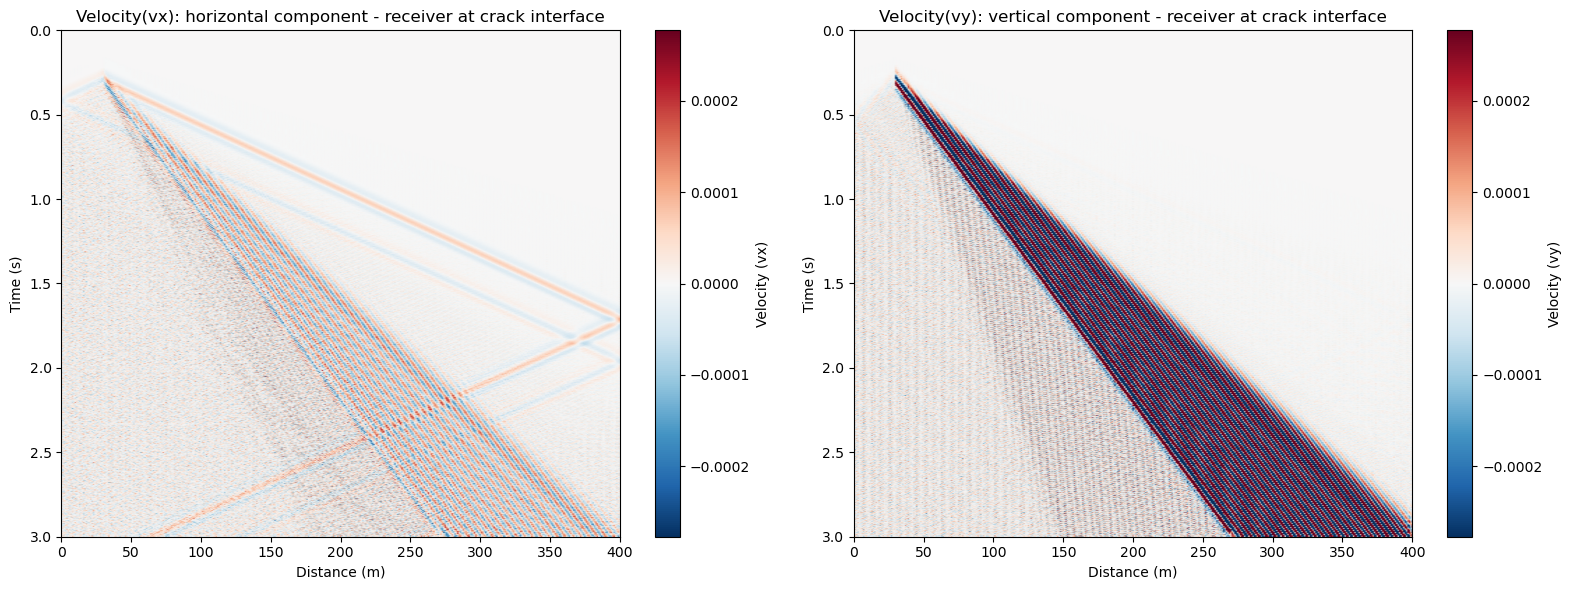

In [19]:
# Force inline display in case backend was set to Agg earlier
import matplotlib.pyplot as plt
from IPython.display import display

# Define receiver line 
y_surface = 2.625 # 

# dis_2d_layered is already an xarray built from all events.
# Use direct selection instead of calling wavefield_output_to_xarray again.
    
# Resolve coordinate / dimension names robustly.
coords_set = set(vel_2d_layered.coords)
dims_set = set(vel_2d_layered.dims)

x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

if x_name is None or y_name is None or t_name is None or c_name is None:
    raise ValueError(f"Could not resolve required dimensions. Found dims={vel_2d_layered.dims}, coords={list(vel_2d_layered.coords)}")

# Select both components at y receiver line
sg_vx = vel_2d_layered.isel({c_name: 0}).sel({y_name: y_surface}, method="nearest")
sg_vy = vel_2d_layered.isel({c_name: 1}).sel({y_name: y_surface}, method="nearest")

# Keep all moving-source events by reducing event dimension to a single stacked section.
if e_name is not None and e_name in sg_vx.dims:
    sg_vx_plot = sg_vx.mean(dim=e_name)
    sg_vy_plot = sg_vy.mean(dim=e_name)
else:
    sg_vx_plot = sg_vx
    sg_vy_plot = sg_vy

# Ensure plotting order is (time, x)
sg_vx_plot = sg_vx_plot.transpose(t_name, x_name)
sg_vy_plot = sg_vy_plot.transpose(t_name, x_name)

t_vals = sg_vx_plot[t_name].values
x_line = sg_vx_plot[x_name].values
data_vx = sg_vx_plot.values
data_vy = sg_vy_plot.values

print("Using dimensions:", {"x": x_name, "y": y_name, "t": t_name, "c": c_name, "event": e_name})
print("t range:", t_vals[0], "->", t_vals[-1])
print("vx shape:", data_vx.shape)
print("vy shape:", data_vy.shape)

# Clip colorscale (use same scale for both for comparison)
vmax = np.percentile(np.abs([data_vx, data_vy]), 95)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot vx (horizontal component)
im_vx = axes[0].pcolormesh(
    x_line,
    t_vals,
    data_vx,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[0].invert_yaxis()

# Mark all moving source positions
# for x_src in x_positions:
#     axes[0].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlim(0, 400)
axes[0].set_title("Velocity(vx): horizontal component - receiver at crack interface")
plt.colorbar(im_vx, ax=axes[0], label="Velocity (vx)")

# Plot vy (vertical component)
im_vy = axes[1].pcolormesh(
    x_line,
    t_vals,
    data_vy,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[1].invert_yaxis()

# # Mark all moving source positions
# for x_src in x_positions:
#     axes[1].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[1].set_xlabel("Distance (m)")
axes[1].set_ylabel("Time (s)")
axes[1].set_xlim(0, 400)
axes[1].set_title("Velocity(vy): vertical component - receiver at crack interface")
plt.colorbar(im_vy, ax=axes[1], label="Velocity (vy)")

plt.tight_layout()

# Display explicitly in notebook output
display(fig)
plt.close(fig)

In [20]:
# displacemnt and strain
moving_source_output_folder = str(pathlib.Path(PROJECT_DIR) / "custom_job_moving_source_all_sources")
# Extract displacement wavefield output from the single combined run.
vol_file = pathlib.Path(moving_source_output_folder) / "volume_data_output.h5"
if not vol_file.exists():
    raise RuntimeError(
        f"Missing output file: {vol_file}. Re-run the launch cell and verify the job completed."
    )

dis_wo = wavefield_output.WavefieldOutput.from_file(
    vol_file,
    "displacement",
    "volume",
)

dis_2d_layered = wavefield_output.wavefield_output_to_xarray(
    dis_wo,
    points=[np.linspace(0, 400, 401), np.linspace(0, 3, 101)],
)

print(f"Loaded displacement from {vol_file}")
print(f"Shape: {dis_2d_layered.dims}")
print(dis_2d_layered)

print(f"WavefieldOutput shape: {dis_wo.data.shape}")
print(f"Shape: {dis_2d_layered.dims}")
print(dis_2d_layered)
print("WavefieldOutput shape:", dis_wo.data.shape)#
print("xarray shape:", dis_2d_layered.shape) 

# Take the spatial derivative of the layered displacement field along x.
x_dim = next((dim for dim in ["x", "X", "p0", "dim_0"] if dim in dis_2d_layered.dims or dim in dis_2d_layered.coords), None)

if x_dim is None:
    raise ValueError(
        f"Could not find an x-like spatial dimension in dims={dis_2d_layered.dims}, coords={list(dis_2d_layered.coords)}"
    )

dis_2d_layered_dx = dis_2d_layered.differentiate(x_dim)

print(f"Computed spatial derivative d/d{x_dim} for dis_2d_layered")
print(dis_2d_layered_dx)


Finding enclosing elements (pass 1 of auto):   0%|          | 0/40501 [00:00<?, ?it/s]

Finding enclosing elements (pass 2 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 3 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 4 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 5 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

Finding enclosing elements (pass 6 of auto):   0%|          | 0/20050 [00:00<?, ?it/s]

[2026-06-12 15:21:00,787] WARNING - salvus.mesh.algorithms.unstructured_mesh.utils: 20050 points were not claimed by enclosing elements. Depending on your use case, this may not be an issue.


Extracting wavefield to regular grid:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded displacement from simulation_wavefield_custom_stf_rolled/custom_job_moving_source_all_sources/volume_data_output.h5
Shape: ('t', 'c', 'x', 'y')
<xarray.DataArray (t: 940, c: 2, x: 401, y: 101)> Size: 305MB
array([[[[            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         ...,
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
         [            nan,             nan,             nan, ...,
           0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],

   

Using dimensions: {'x': 'x', 'y': 'y', 't': 't', 'c': 'c', 'event': None}
t range: 0.0 -> 3.0008948355207097
vx shape: (940, 401)
vy shape: (940, 401)


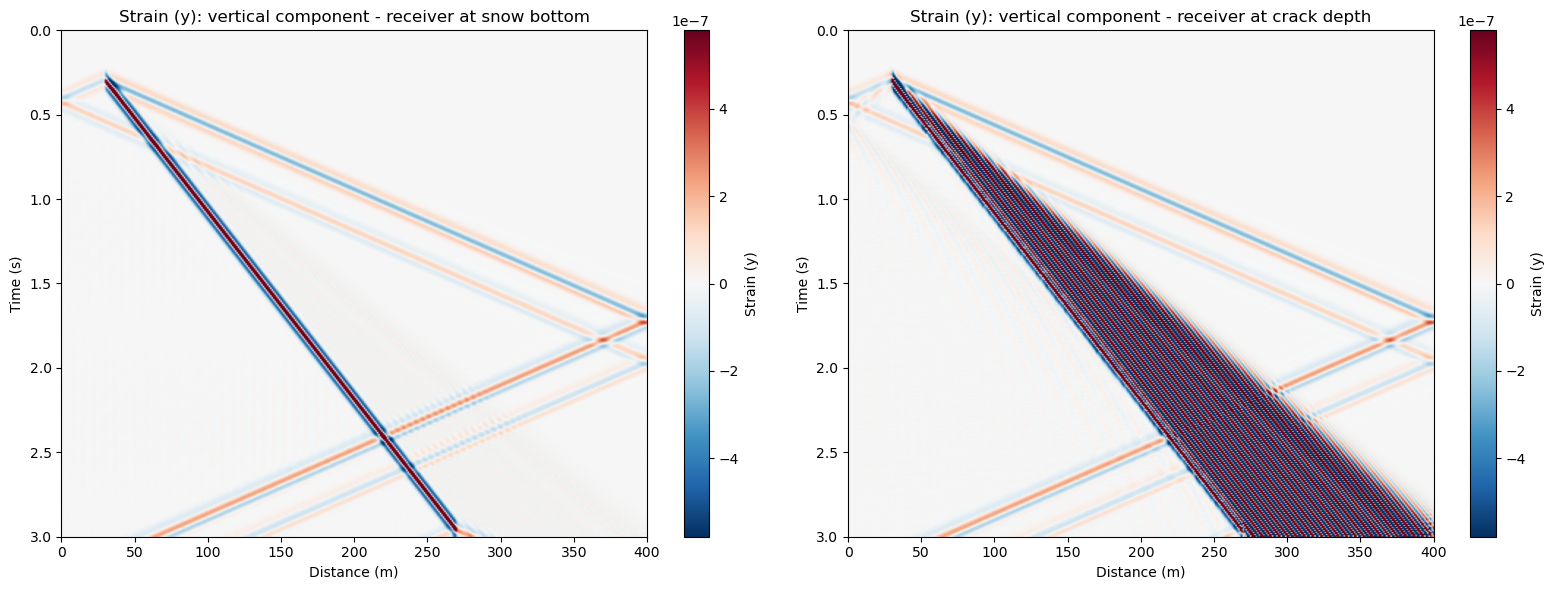

In [21]:
# Plottining strain for two different reciever lines 
# Force inline display in case backend was set to Agg earlier
import matplotlib.pyplot as plt
from IPython.display import display

# Define receiver line at snow-earth interface (model coordinates)
y_surface_1 = 2.25
y_surface_2 = 2.625

# dis_2d_layered is already an xarray built from all events.
# Use direct selection instead of calling wavefield_output_to_xarray again.
    
# Resolve coordinate / dimension names robustly.
coords_set = set(vel_2d_layered.coords)
dims_set = set(vel_2d_layered.dims)

x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

if x_name is None or y_name is None or t_name is None or c_name is None:
    raise ValueError(f"Could not resolve required dimensions. Found dims={vel_2d_layered.dims}, coords={list(vel_2d_layered.coords)}")

# Select both components at y receiver line
sg_strain_y_1 = dis_2d_layered_dx.isel({c_name: 0}).sel({y_name: y_surface_1}, method="nearest")
sg_strain_y_2 = dis_2d_layered_dx.isel({c_name: 0}).sel({y_name: y_surface_2}, method="nearest")

# Keep all moving-source events by reducing event dimension to a single stacked section.
if e_name is not None and e_name in sg_strain_y_1.dims:
    sg_strain_y_1_plot = sg_strain_y_1.mean(dim=e_name)
    sg_strain_y_2_plot = sg_strain_y_2.mean(dim=e_name)
else:
    sg_strain_y_1_plot = sg_strain_y_1
    sg_strain_y_2_plot = sg_strain_y_2

# Ensure plotting order is (time, x)
sg_strain_y_1_plot = sg_strain_y_1_plot.transpose(t_name, x_name)
sg_strain_y_2_plot = sg_strain_y_2_plot.transpose(t_name, x_name)

t_vals = sg_strain_y_1_plot[t_name].values
x_line = sg_strain_y_1_plot[x_name].values
data_vx = sg_strain_y_1_plot.values
data_vy = sg_strain_y_2_plot.values

print("Using dimensions:", {"x": x_name, "y": y_name, "t": t_name, "c": c_name, "event": e_name})
print("t range:", t_vals[0], "->", t_vals[-1])
print("vx shape:", data_vx.shape)
print("vy shape:", data_vy.shape)

# Clip colorscale (use same scale for both for comparison)
vmax = np.percentile(np.abs([data_vx, data_vy]), 95)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot vx (horizontal component)
im_vx = axes[0].pcolormesh(
    x_line,
    t_vals,
    data_vx,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[0].invert_yaxis()

# Mark all moving source positions
# for x_src in x_positions:
#     axes[0].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlim(0, 400)
axes[0].set_title("Strain (y): vertical component - receiver at snow bottom")
plt.colorbar(im_vx, ax=axes[0], label="Strain (y)")

# Plot vy (vertical component)
im_vy = axes[1].pcolormesh(
    x_line,
    t_vals,
    data_vy,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[1].invert_yaxis()

# # Mark all moving source positions
# for x_src in x_positions:
#     axes[1].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[1].set_xlabel("Distance (m)")
axes[1].set_ylabel("Time (s)")
axes[1].set_xlim(0, 400)
axes[1].set_title("Strain (y): vertical component - receiver at crack depth")
plt.colorbar(im_vy, ax=axes[1], label="Strain (y)")

plt.tight_layout()

# Display explicitly in notebook output
display(fig)
plt.close(fig)
